# CoxPH Algorithm Test using the MockNetwork
The mock network is intended for testing algorithms without the need of setting up an 
entire vantage6 network.

In [1]:
import pandas as pd

## MockClient
We mock to have two organizations with three databases each (<code>rps_cohort</code>, <code>pelvis_cohort</code> and <code>rps_pelvis_cohort</code>). <br><br>
The first organization has:
* <code>rps_cohort[:10]</code> (10 pts)
* <code>pelvis_cohort[:10]</code> (10 pts)
* <code>rps_pelvis_cohort[:10]</code> (10 pts)

The second organization has:
* <code>rps_cohort[10:]</code> (304 pts)
* <code>pelvis_cohort[10:]</code> (276 pts)
* <code>non_liposarcoma_cohort[10:]</code> (590 pts)

In [3]:
# Load the dataframes from parquet files
rps_cohort = pd.read_parquet("../data/rps_cohort.parquet")
pelvis_cohort = pd.read_parquet("../data/pelvis_cohort.parquet")
rps_pelvis_cohort = pd.read_parquet("../data/rps_pelvis_cohort.parquet")


In [13]:
# Temporary set the survival_days to the delta between the surgery date and today
rps_cohort["survival_days"] = (pd.Timestamp("2026-01-01", tz="UTC") - rps_cohort["surgery_date"]).dt.days.astype("Int64")
pelvis_cohort["survival_days"] = (pd.Timestamp("2026-01-01", tz="UTC") - pelvis_cohort["surgery_date"]).dt.days.astype("Int64")
rps_pelvis_cohort["survival_days"] = (pd.Timestamp("2026-01-01", tz="UTC") - rps_pelvis_cohort["surgery_date"]).dt.days.astype("Int64")


In [14]:
from vantage6.algorithm.mock.network import MockNetwork

network = MockNetwork(
    "v6-analytics",
    datasets=[
        {
            "rps": {"database": rps_cohort[:20], "db_type": "omop"},
            "pelvis": {"database": pelvis_cohort[:20], "db_type": "omop"},
            "rps_pelvis": {"database": rps_pelvis_cohort[:20], "db_type": "omop"}
        },
        {
            "rps": {"database": rps_cohort[20:], "db_type": "omop"},
            "pelvis": {"database": pelvis_cohort[20:], "db_type": "omop"},
            "rps_pelvis": {"database": rps_pelvis_cohort[20:], "db_type": "omop"}
        }
    ],
    collaboration_id=1,
)

client = network.user_client

[info ] - Mock network created with 2 nodes


In [41]:
network.get_node(2).dataframes['rps'].head()

,patient_id,age,sex,censor,status,survival_days,histology,fnclcc_grade,tumor_size,surgery_date,...,completeness_of_resection,completeness_of_resection_concept_id,tumor_rupture,pre_operative_chemo,post_operative_chemo,pre_operative_radio,post_operative_radio,local_recurrence,distant_metastasis,n_cancer_episodes
20,43,53,MALE,False,ALIVE,900,1022 Other sarcomas,Grade 2 tumor,1.2,2023-07-16 00:00:00+00:00,...,Macroscopically complete,1633801,False,False,True,True,False,False,False,1
21,45,65,FEMALE,True,DEAD,489,1016 MPNST,Grade 3 tumor,<NA>,2024-08-30 00:00:00+00:00,...,Macroscopically complete,1634643,False,False,False,True,False,False,False,1
22,46,57,FEMALE,False,ALIVE,2615,1022 Other sarcomas,Grade 1 tumor,<NA>,2018-11-04 00:00:00+00:00,...,Macroscopically incomplete,1634484,False,False,False,False,True,False,False,1
23,47,61,FEMALE,False,ALIVE,455,1010 Leiomyosarcoma,Grade 1 tumor,5.7,2024-10-03 00:00:00+00:00,...,Macroscopically complete,1633801,False,True,False,True,False,False,False,1
24,49,18,MALE,False,ALIVE,532,1019 UPS,Grade 3 tumor,3.3,2024-07-18 00:00:00+00:00,...,Macroscopically complete,1633801,False,True,False,True,False,False,False,1


In [42]:
# overall summary results
task = client.task.create(
    method="coxph_central",
    organizations=[1],
    arguments={
        "time_col": "survival_days",
        "outcome_col": "censor",	
        "expl_vars": ["age", "age"],
        "organizations_to_include": [1,2]
    },
    databases=[
        [
            {"type": "dataframe", "dataframe_id": 1},
            {"type": "dataframe", "dataframe_id": 2},
            {"type": "dataframe", "dataframe_id": 3}
        ]
    ],
    action="central_compute"
)

[info ] - Validating function action: central_compute
info > Sending task to organizations [1, 2]
[info ] - Validating function action: federated_compute
info > Computing unique event times
info > Computing unique event times
info > Computing unique event times
[info ] - Validating function action: federated_compute
info > Computing unique event times
info > Computing unique event times
info > Computing unique event times
info > Child task created with id=53
info > Waiting for results
info > Results obtained!
[info ] - Validating function action: federated_compute
info > Computing summed z statistics
info > Computing summed z statistics
info > Computing summed z statistics
[info ] - Validating function action: federated_compute
info > Computing summed z statistics
info > Computing summed z statistics
info > Computing summed z statistics
info > Child task created with id=54
info > Waiting for results
info > Results obtained!
info > Iteration 1
[info ] - Validating function action: feder

AttributeError: 'float' object has no attribute 'exp'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/frank/repositories/idea4rc-vantage6-algorithms/.venv/lib/python3.13/site-packages/vantage6/algorithm/mock/client.py", line 252, in create
    result = node.simulate_task_run(
        method=method,
    ...<2 lines>...
        action=action,
    )
  File "/home/frank/repositories/idea4rc-vantage6-algorithms/.venv/lib/python3.13/site-packages/vantage6/algorithm/mock/node.py", line 158, in simulate_task_run
    result = self.run(
        method_fn,
        {**arguments, **mocked_kwargs},
        task_env_vars=task_env_vars,
    )
  File "/home/frank/repositories/idea4rc-vantage6-algorithms/.venv/lib/python3.13/site-packages/vantage6/algorithm/mock/node.py", line 262, in run
    return method_fn(**arguments)
  File "/home/frank/repositories/idea4rc-vantage6-algorithms/.venv/lib/python3.13/site-packages/vantage6/algorit

error > Error simulating task run for organization 1: name 'exit' is not defined


AttributeError: 'float' object has no attribute 'exp'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/frank/repositories/idea4rc-vantage6-algorithms/.venv/lib/python3.13/site-packages/vantage6/algorithm/mock/client.py", line 252, in create
    result = node.simulate_task_run(
        method=method,
    ...<2 lines>...
        action=action,
    )
  File "/home/frank/repositories/idea4rc-vantage6-algorithms/.venv/lib/python3.13/site-packages/vantage6/algorithm/mock/node.py", line 158, in simulate_task_run
    result = self.run(
        method_fn,
        {**arguments, **mocked_kwargs},
        task_env_vars=task_env_vars,
    )
  File "/home/frank/repositories/idea4rc-vantage6-algorithms/.venv/lib/python3.13/site-packages/vantage6/algorithm/mock/node.py", line 262, in run
    return method_fn(**arguments)
  File "/home/frank/repositories/idea4rc-vantage6-algorithms/.venv/lib/python3.13/site-packages/vantage6/algorit

NameError: name 'exit' is not defined

In [37]:
results = client.result.from_task(task_id=task.get("id"))
results

[{'cohorts': {'rps': {'included_organizations': [1, 2],
    'excluded_organizations': [],
    'model': '{"Coef":{"age":-0.00343},"Exp(coef)":{"age":0.99658},"SE":{"age":0.00497},"lower_CI":{"age":0.98692},"upper_CI":{"age":1.00633},"Z":{"age":-0.6884789238},"p-value":{"age":0.4911512382}}',
    'overall_p_value': 0.49040843929428235,
    'aic': 1372.5251095159635,
    'degrees_of_freedom': 1,
    'warnings': [],
    'converged': True},
   'pelvis': {'included_organizations': [1, 2],
    'excluded_organizations': [],
    'model': '{"Coef":{"age":0.00668},"Exp(coef)":{"age":1.0067},"SE":{"age":0.00487},"lower_CI":{"age":0.99714},"upper_CI":{"age":1.01636},"Z":{"age":1.3751693022},"p-value":{"age":0.169078963}}',
    'overall_p_value': 0.17050526736033011,
    'aic': 1386.3070386258005,
    'degrees_of_freedom': 1,
    'warnings': [],
    'converged': True},
   'rps_pelvis': {'included_organizations': [1, 2],
    'excluded_organizations': [],
    'model': '{"Coef":{"age":0.00155},"Exp(coe

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cohorts = results[0]["cohorts"]
rows = []
for cohort_name, data in cohorts.items():
    if "model" not in data:
        print(f"Cohort '{cohort_name}' failed: {data.get('msg', 'unknown error')}")
        continue
    model = json.loads(data["model"])
    for var in model["Coef"]:
        rows.append({
            "cohort": cohort_name,
            "variable": var,
            "HR": model["Exp(coef)"][var],
            "lower_CI": model["lower_CI"][var],
            "upper_CI": model["upper_CI"][var],
            "p_value": model["p-value"][var],
        })

df = pd.DataFrame(rows)
df

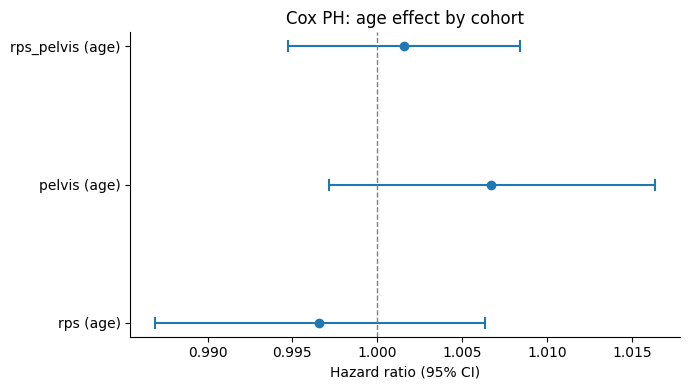

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))

y_pos = np.arange(len(df))
ax.errorbar(
    df["HR"],
    y_pos,
    xerr=[df["HR"] - df["lower_CI"], df["upper_CI"] - df["HR"]],
    fmt="o",
    capsize=4,
    capthick=1.5,
)

ax.axvline(1, color="gray", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r.cohort} ({r.variable})" for _, r in df.iterrows()])
ax.set_xlabel("Hazard ratio (95% CI)")
ax.set_title("Cox PH: age effect by cohort")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [40]:
display_df = df.assign(
    HR_95CI=df.apply(lambda r: f"{r['HR']:.3f} ({r['lower_CI']:.3f}–{r['upper_CI']:.3f})", axis=1),
    p_value=df["p_value"].round(4),
)[["cohort", "variable", "HR_95CI", "p_value"]]
display_df

,cohort,variable,HR_95CI,p_value
0,rps,age,0.997 (0.987–1.006),0.4912
1,pelvis,age,1.007 (0.997–1.016),0.1691
2,rps_pelvis,age,1.002 (0.995–1.008),0.6557
